In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from lyapynov import ContinuousDS
from lyapynov import LCE


In [2]:
# extremum seeking parameters
alpha = 0.1 #dither amplitude
omega_x = 15 #x dither frequency
omega_y = 23 #y dither frequency
omega_n = 1 #high pass filter cutoff frequency
k = 3  #learning rate

#cost function parameters
qx = 0.5
qy = 0.5
f_star = 1.0

#simulation parameters
t0 = 0.
dt = 1e-2

def rhs_auto(z, t):
            
            x, y, eta, mx, cx, my, cy = z

            J = f_star - qx*x**2 - qy*y**2 #quadratic cost function
            e = J - eta

            dx = k*e*mx + alpha*omega_x*cx
            dy = k*e*my + alpha*omega_y*cy
            deta = omega_n*e

            dmx = omega_x*cx
            dcx = -omega_x*mx
            dmy = omega_y*cy
            dcy = -omega_y*my

            return np.array([dx, dy, deta, dmx, dcx, dmy, dcy])

def jac_auto(z, t):
    x, y, eta, mx, cx, my, cy = z
    e = (f_star - qx*x**2 - qy*y**2) - eta
    
    J_mat = np.zeros((7, 7))
    
    #dx
    J_mat[0, 0] = -2*k*qx*x*mx   
    J_mat[0, 1] = -2*k*qy*y*mx   
    J_mat[0, 2] = -k*mx          
    J_mat[0, 3] = k*e            
    J_mat[0, 4] = alpha*omega_x  
    
    #dy
    J_mat[1, 0] = -2*k*qx*x*my   
    J_mat[1, 1] = -2*k*qy*y*my   
    J_mat[1, 2] = -k*my          
    J_mat[1, 5] = k*e            
    J_mat[1, 6] = alpha*omega_y  
    
    # deta
    J_mat[2, 0] = -2*omega_n*qx*x 
    J_mat[2, 1] = -2*omega_n*qy*y 
    J_mat[2, 2] = -omega_n       
    
    # dmx
    J_mat[3, 4] = omega_x        
    J_mat[4, 3] = -omega_x       
    J_mat[5, 6] = omega_y        
    J_mat[6, 5] = -omega_y       
    
    return J_mat

x0 = np.array([
    2, #x initial
    2, #y initial
    0, #eta
    np.sin(omega_x*t0),
    np.cos(omega_x*t0),
    np.sin(omega_y*t0),
    np.cos(omega_y*t0),
])
Lorenz63 = ContinuousDS(x0, t0, rhs_auto, jac_auto, dt)
Lorenz63.forward(10**6, False)

[-1.20074183e-01 -2.65132210e-02 -1.00060015e+00 -7.88790956e-06
 -7.88790956e-06 -1.02123022e-04 -1.02123022e-04]


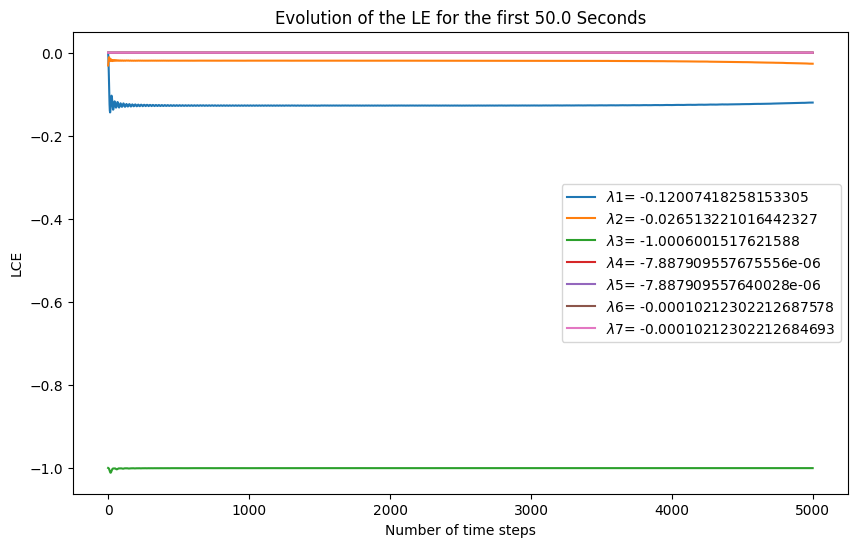

In [10]:
LCE_esc, history = LCE(Lorenz63, 7, 0, int(50/dt), True)
print(LCE_esc)
plt.figure(figsize = (10,6))
plt.plot(history[:5000])
plt.xlabel("Number of time steps")
plt.ylabel("LCE")
plt.title("Evolution of the LE for the first 50.0 Seconds")
plt.legend([r"$\lambda$"+str(i)+"= "+str(LCE_esc[i-1]) for i in range(1,8)])
plt.show()

True The solver successfully reached the end of the integration interval. 29.990000000000002 (3000, 7)


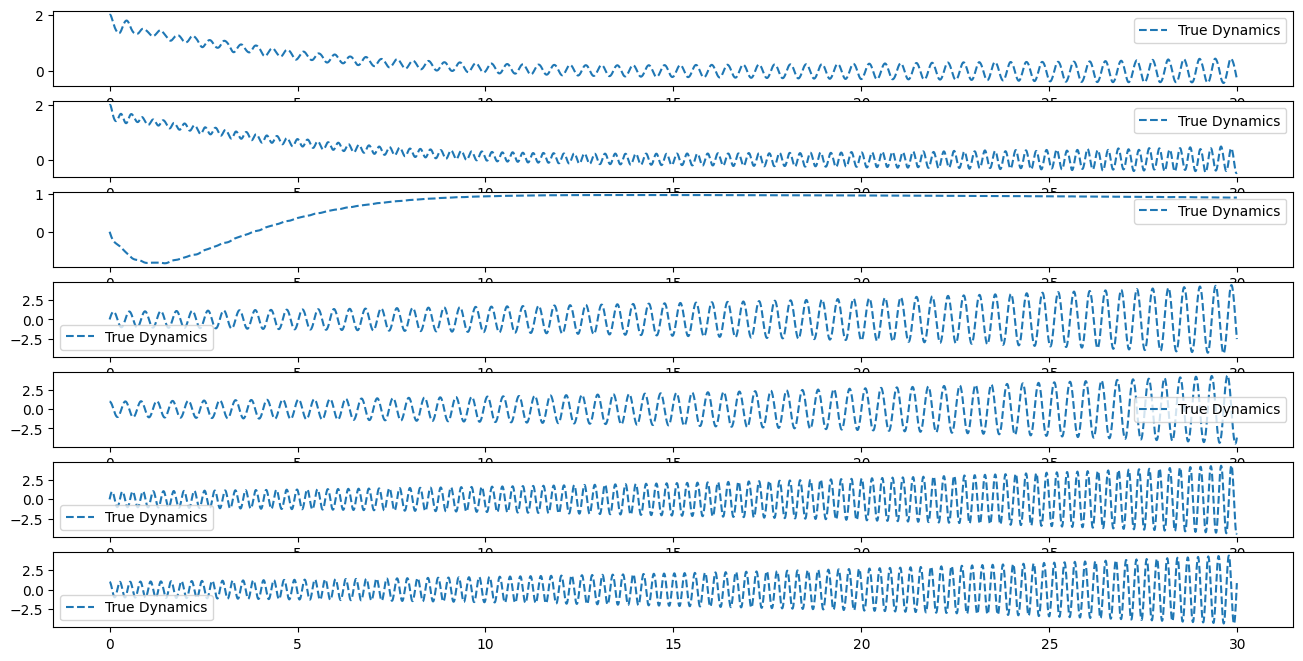

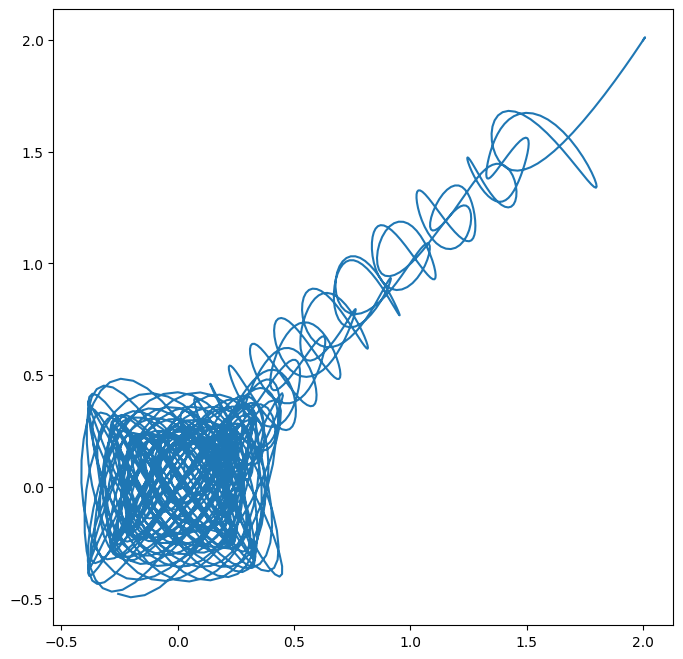

In [4]:
# Augmented ESC parameters - added growth rate epsilon to trig terms
epsilon = 0.05 #trig growth rate

alpha = 0.1 #dither amplitude
omega_x = 15 #x dither frequency
omega_y = 23 #y dither frequency
omega_n = 1 #high pass filter cutoff frequency
k = 3  #learning rate

#cost function parameters
qx = 0.5
qy = 0.5
f_star = 1.0

#simulation parameters
t0 = 0.
dt = 1e-2

def rhs_auto_unstable(z, t):
            
            x, y, eta, mx, cx, my, cy = z

            J = f_star - qx*x**2 - qy*y**2 #quadratic cost function
            e = J - eta

            dx = k*e*mx + alpha*omega_x*cx
            dy = k*e*my + alpha*omega_y*cy
            deta = omega_n*e

            dmx = epsilon*mx + omega_x*cx
            dcx = epsilon*cx - omega_x*mx
            dmy = epsilon*my + omega_y*cy
            dcy = epsilon*cy - omega_y*my

            return np.array([dx, dy, deta, dmx, dcx, dmy, dcy])

def jac_auto_unstable(z, t):
    x, y, eta, mx, cx, my, cy = z
    e = (f_star - qx*x**2 - qy*y**2) - eta
    
    J_mat = np.zeros((7, 7))
    
    #dx
    J_mat[0, 0] = -2*k*qx*x*mx   
    J_mat[0, 1] = -2*k*qy*y*mx   
    J_mat[0, 2] = -k*mx          
    J_mat[0, 3] = k*e            
    J_mat[0, 4] = alpha*omega_x  
    
    #dy
    J_mat[1, 0] = -2*k*qx*x*my   
    J_mat[1, 1] = -2*k*qy*y*my   
    J_mat[1, 2] = -k*my          
    J_mat[1, 5] = k*e            
    J_mat[1, 6] = alpha*omega_y  
    
    # deta
    J_mat[2, 0] = -2*omega_n*qx*x 
    J_mat[2, 1] = -2*omega_n*qy*y 
    J_mat[2, 2] = -omega_n       
    
    # dmx
    J_mat[3, 3] = epsilon
    J_mat[3, 4] = omega_x

    J_mat[4, 3] = -omega_x       
    J_mat[4, 4] = epsilon

    J_mat[5, 6] = omega_y
    J_mat[5, 5] = epsilon

    J_mat[6, 5] = -omega_y
    J_mat[6, 6] = epsilon       
    
    return J_mat

x0 = np.array([
    2, #x initial
    2, #y initial
    0, #eta
    np.sin(omega_x*t0),
    np.cos(omega_x*t0),
    np.sin(omega_y*t0),
    np.cos(omega_y*t0),
])


t_span = np.array([0,30])
t_eval = np.arange(0,30,0.01)
sol = solve_ivp(fun=lambda z,t: rhs_auto_unstable(t,z), t_eval=t_eval, t_span=t_span, y0=x0, rtol=1e-6)
print(sol.success, sol.message, sol.t[-1], sol.y.T.shape)


x = sol.y.T
t = sol.t

fig = plt.figure(figsize=(16, 8))
c = 1
n = x.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, x[:, d], "--", label = 'True Dynamics',)
    c = c + 1
    plt.legend()

fig2 = plt.figure(figsize=(8,8))
plt.plot(x[:,0],x[:,1])

[-0.864253   -2.73067145 -5.66955971  0.04999107  0.04999107  0.04989221
  0.04989221]


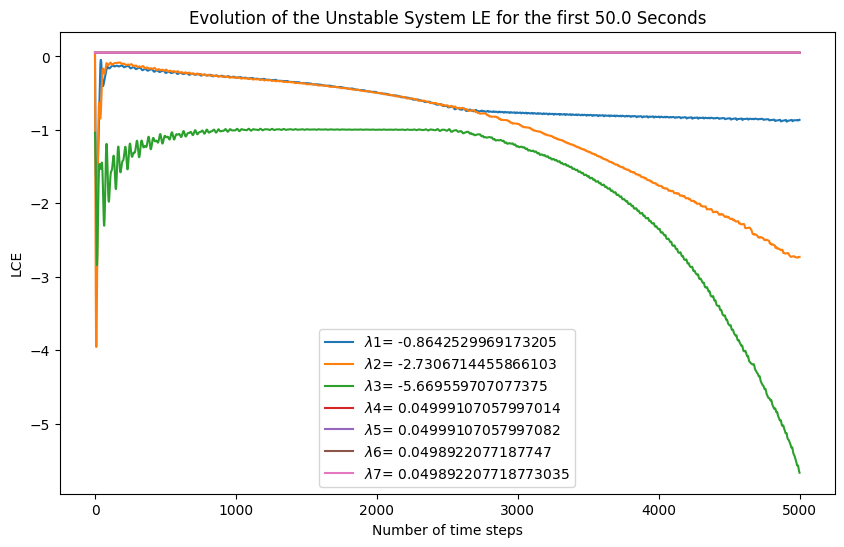

In [9]:
esc_unstable = ContinuousDS(x0, t0, rhs_auto_unstable, jac_auto_unstable, dt)
# esc_unstable.forward(10**6, False)
# print(type(LCE))
LCE_esc_unstable, history = LCE(esc_unstable, 7, 0, int(50/dt), True)
print(LCE_esc_unstable)
plt.figure(figsize = (10,6))
plt.plot(history[:])
plt.xlabel("Number of time steps")
plt.ylabel("LCE")
plt.title(f"Evolution of the Unstable System LE for the first {5000*dt} Seconds")
plt.legend([r"$\lambda$"+str(i)+"= "+str(LCE_esc_unstable[i-1]) for i in range(1,8)])
plt.show()
